In [2]:
import scanpy as sc
import anndata
from scipy import io
import scipy
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pickle
import pandas as pd
import matplotlib.pyplot as pl
from matplotlib import rcParams

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

sc.settings.set_figure_params(facecolor='white', dpi=100, frameon=False)

import matplotlib.colors

### original location

In [11]:
work_dir = '/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/reference_map_by_dev_stage/'

orig_ref = pickle.load(open(os.path.join(work_dir, 'ref_repeat.pkl'), 'rb'))

### location for Zenodo

In [23]:
work_dir = '/share/crsp/lab/dalawson/tzhuravl/PROJECT_DATA_INFO_LINKS_etc/objects_for_zenodo'

pickle.dump(orig_ref,
            open(os.path.join(work_dir, 'mouse_atlas_reference.pkl'), 'wb'))

### clean-up

In [12]:
orig_ref.obs.drop(columns=['cell_type'], inplace=True)

In [13]:
orig_ref.obs['cell_type_ref'] = (
    orig_ref.obs["cell_type_ref"]
    .map(lambda x: {"Basal_myoep_proliferating": "B_prolif",
                    "Basal_proliferating": "basal",
                    "LumSec_basal_myo_proliferating": "L_prolif",
                    "Lactating": "lactocytes",
                   "Hybrid": "hybrid",
                   "Basal_myoepithelial": "Bmyo",
                   "Luminal_Sec": "LumSec",
                   "Luminal_HS": "LumHS",}.get(x, x))
    .astype("category")
)

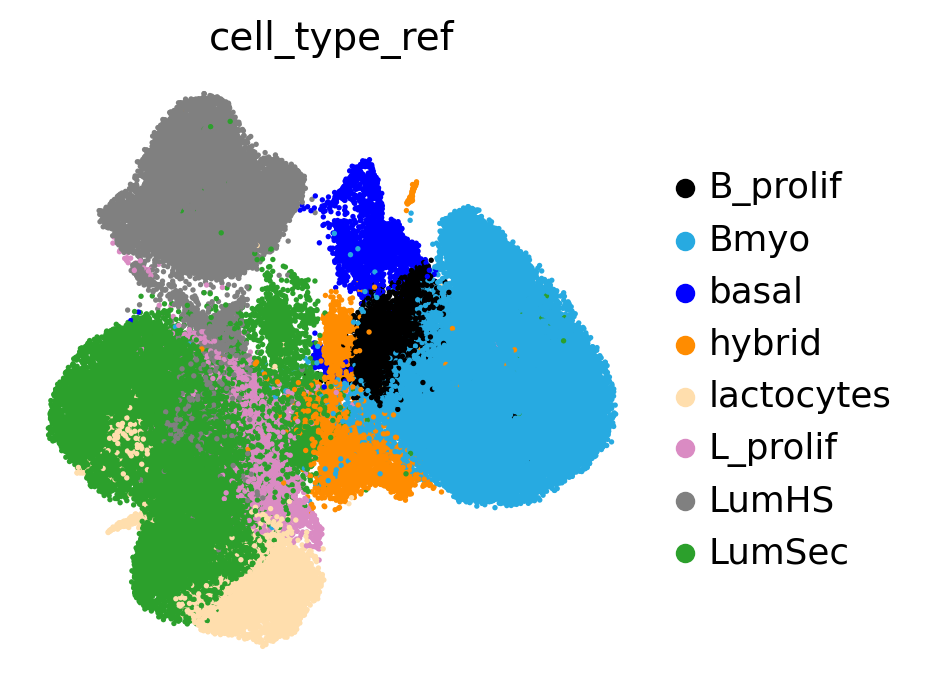

In [14]:
sc.pl.umap(
    orig_ref,
    color=["cell_type_ref"],
    frameon=False,
    ncols=1,s=15
)

In [15]:
orig_ref.obs.drop(columns=['ref_dev_stage'], inplace=True)

In [16]:
orig_ref.obs.drop(columns=['highlight'], inplace=True)

In [17]:
orig_ref.obs.drop(columns=['dev_stage'], inplace=True)

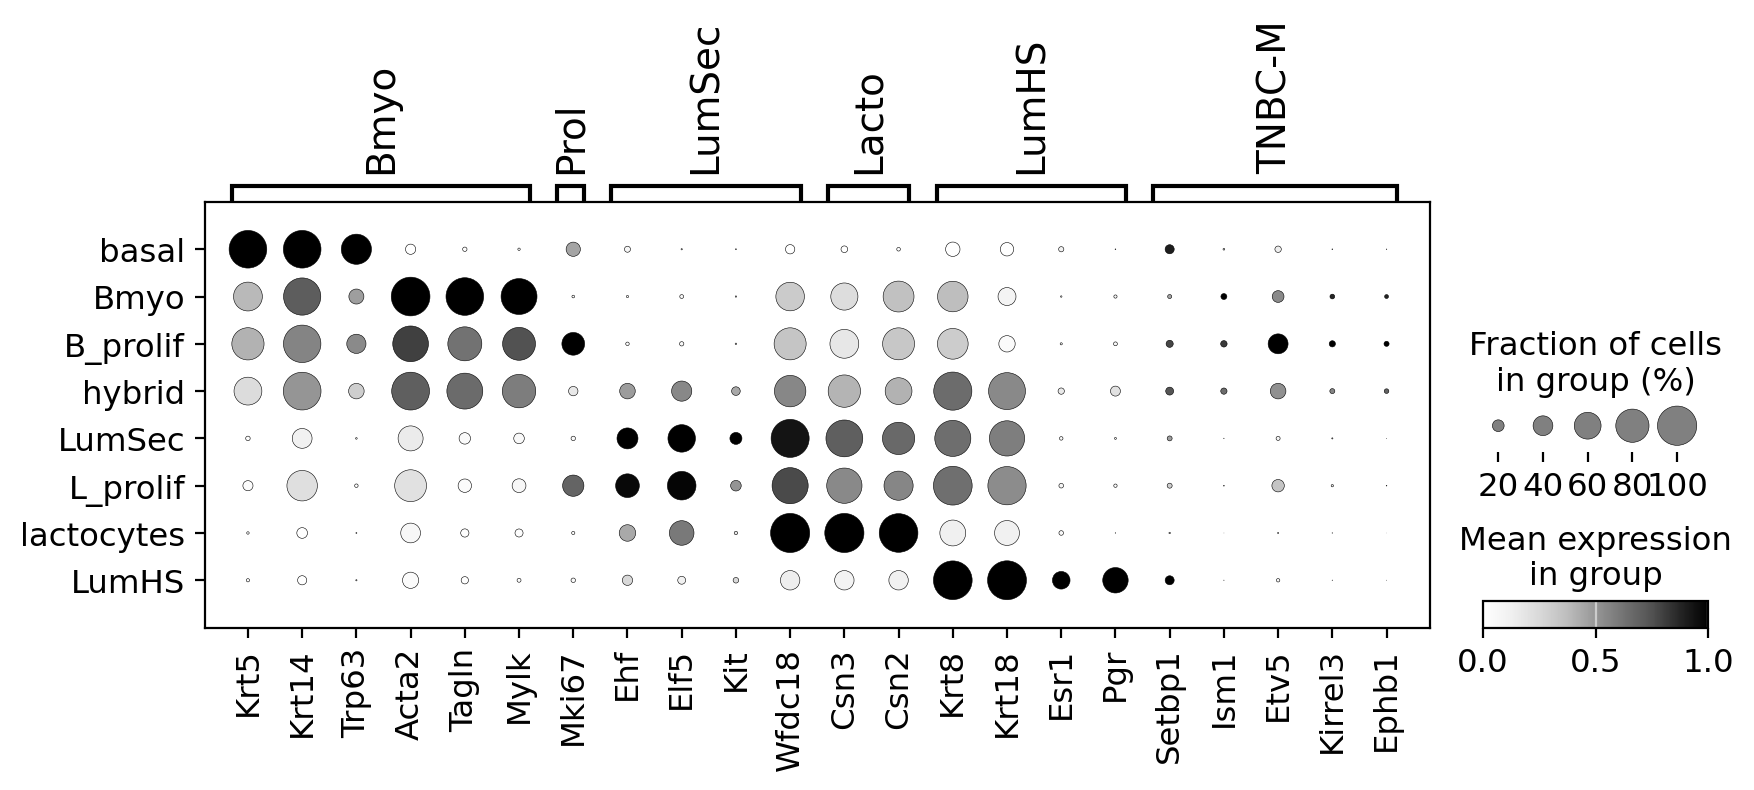

In [17]:
marker_genes = {
    "Bmyo": ["Krt5","Krt14","Trp63","Acta2","Tagln","Mylk"],
    "Prol": ["Mki67"],
    "LumSec": ["Ehf","Elf5","Kit","Wfdc18"],
    "Lacto": ["Csn3","Csn2"],
    "LumHS": ["Krt8","Krt18","Esr1","Pgr"],
    "TNBC-M":["Setbp1","Ism1","Etv5","Kirrel3","Ephb1"]}


sc.pl.dotplot(orig_ref, marker_genes, groupby="cell_type_ref",
              standard_scale="var",
              categories_order=['basal','Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS'],
              swap_axes=False,cmap='Greys',save='_ref_canonical_M.pdf')

In [18]:
tcga=pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/TCGA/tcga_mesenchymal_genes_as_mouse.csv")

In [19]:
tcga=tcga['genes_upper'].to_list()

       'C14orf37', 'C12orf73', '4930503l19rik', 'Sstr4',
       ...
       'Accn2', 'Maged4b', 'C12orf53', 'Gdf1', 'Fam101b', 'Geft', 'C20orf117',
       'C1orf133', '1700030k09rik', 'D630045j12rik'],
      dtype='object', length=259)


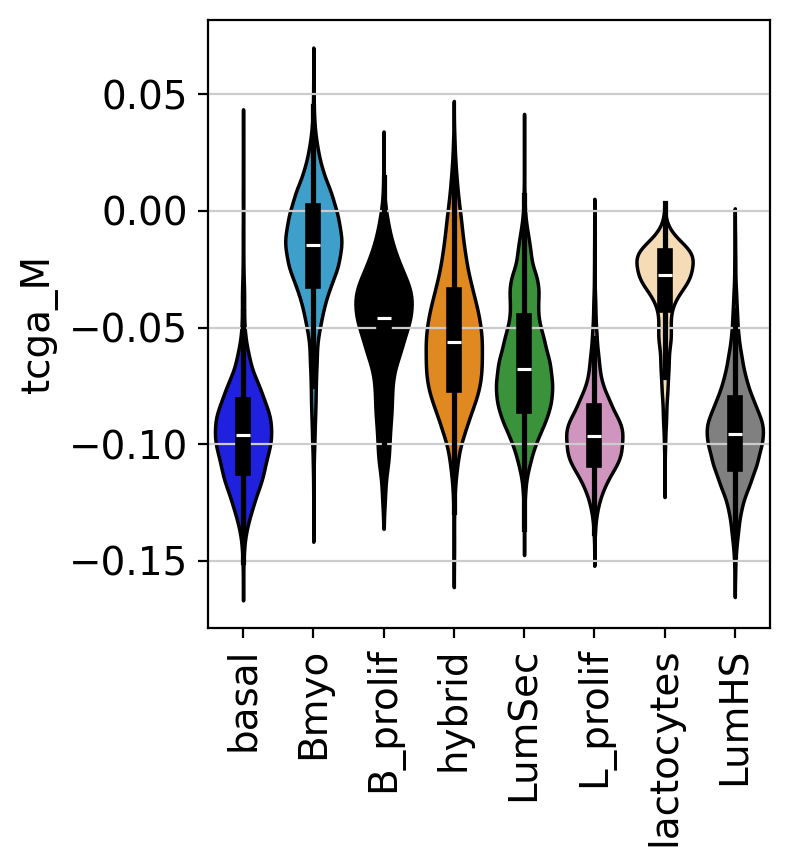

In [20]:
sc.tl.score_genes(orig_ref, tcga,
                  gene_pool=None, n_bins=25, score_name='tcga_M', 
                  random_state=0, copy=False, use_raw=None)

pl.rcParams["figure.figsize"] = (4, 4)
sc.pl.violin(orig_ref, ["tcga_M"], groupby="cell_type_ref", 
             rotation=90, 
             stripplot=False,
             order=['basal','Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS'],
             inner='box',
             #save='_ref_mesenchymal_scores.pdf'
            )

In [21]:
orig_ref.obs['Fig_5_ident'] = (
    orig_ref.obs["orig.ident"]
    .map(lambda x: {"E18-ME": "Embryonic Day 18",
                    "Pre-D5-BL6": "Postnatal Day 5",
                    "Adult-BL6": "Adult Week 10",
                   "E18-Skin": "Embryonic Day 18 skin",
                    "Pre-BL6": "Prepuberty Week 2",
                    "Duct": "Puberty Week 5 Duct",
                    "TEB": "Puberty Week 5 TEB",
                    "Preg-D12": "Pregnancy Day 12",
                    "Preg-D12-G": "Pregnancy Day 12",
                    "Preg-D18": "Pregnancy Day 18",
                    "Preg-D18-B4": "Pregnancy Day 18",
                    "Lac-D10": "Lactation Day 10",
                    "Lac-D10-D6": "Lactation Day 10",
                    "PI-W3": "Post-involution Day 21"}.get(x, x))
    .astype("category")
)

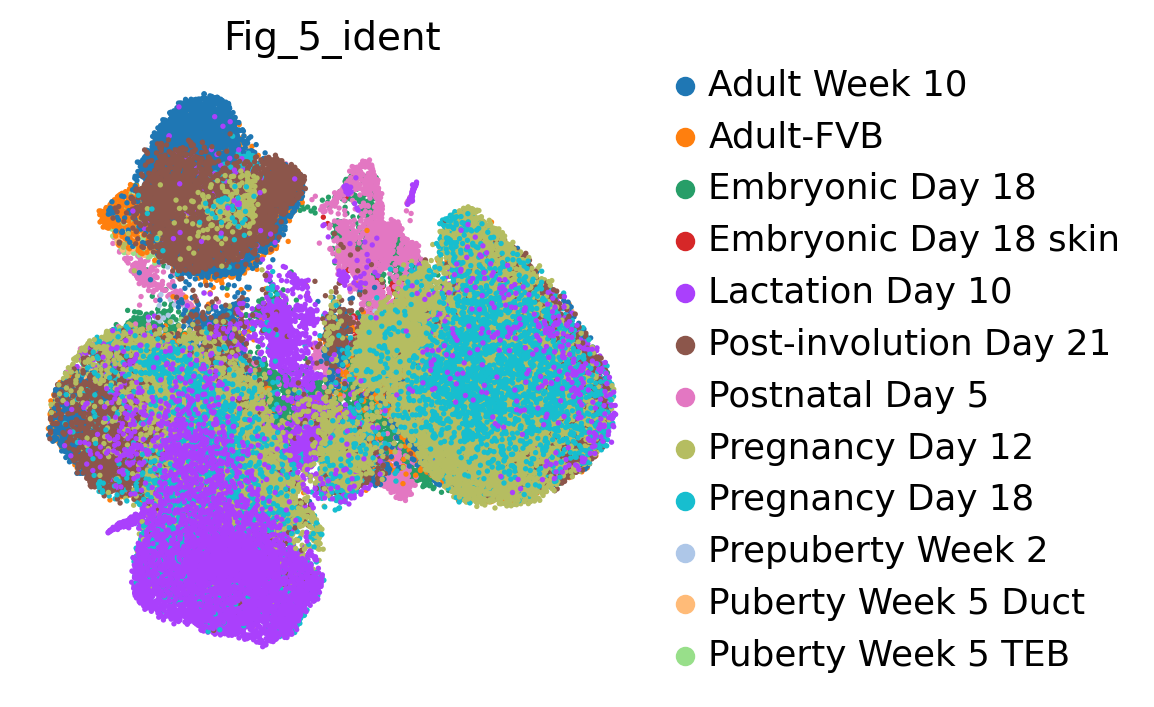

In [22]:
sc.pl.umap(
    orig_ref,
    color=["Fig_5_ident"],
    frameon=False,
    ncols=1,s=15,#save='_ref_origident.pdf'
    #palette=['black', '#27AAE1','blue','darkorange','navajowhite','#da8bc3',
                         #'grey','#2ca02c']
)